In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

RANDOM_STATE = 42
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']
GENRE_COLORS = dict(zip(GENRES, sns.color_palette('Set2', 10)))

In [2]:
df30 = pd.read_csv('Data/features_30_sec.csv')
df3  = pd.read_csv('Data/features_3_sec.csv')

print(f'features_30_sec : {df30.shape}  →  {df30.shape[0]} clips, {df30.shape[1]} colonnes')
print(f'features_3_sec  : {df3.shape}   →  {df3.shape[0]} fenêtres, {df3.shape[1]} colonnes')

features_30_sec : (1000, 60)  →  1000 clips, 60 colonnes
features_3_sec  : (9990, 60)   →  9990 fenêtres, 60 colonnes


In [3]:
df30.info()
print('\nValeurs manquantes :')
print(df30.isnull().sum()[df30.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

In [4]:
df3.info()
print('\nValeurs manquantes :')
print(df3.isnull().sum()[df3.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

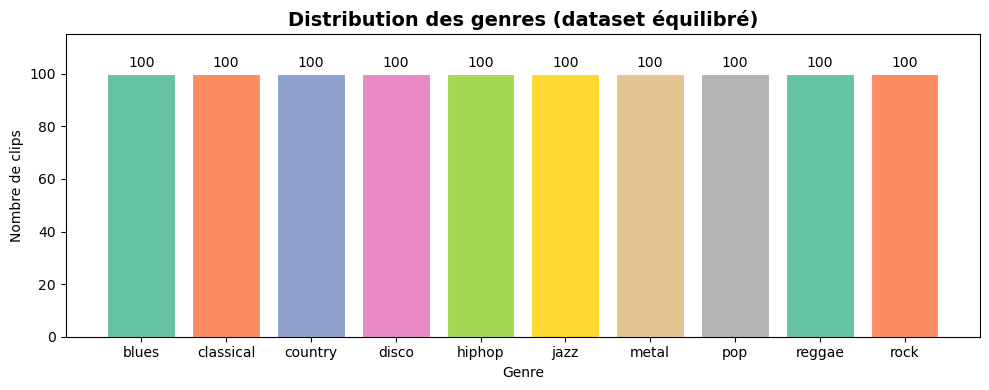

In [5]:
# Distribution des genres
fig, ax = plt.subplots(figsize=(10, 4))
genre_counts = df30['label'].value_counts()[GENRES]
bars = ax.bar(genre_counts.index,
              genre_counts.values,
              color=[GENRE_COLORS[g] for g in genre_counts.index],
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
ax.set_title('Distribution des genres (dataset équilibré)', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Nombre de clips')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

In [6]:
# Colonnes features (on exclut filename et label)
feature_cols = [c for c in df30.columns if c not in ['filename', 'label', 'length']]
print(f'{len(feature_cols)} features disponibles :')

# Regroupement par famille
mfcc_cols     = [c for c in feature_cols if 'mfcc' in c]
chroma_cols   = [c for c in feature_cols if 'chroma' in c]
spectral_cols = [c for c in feature_cols if 'spectral' in c]
other_cols    = [c for c in feature_cols if c not in mfcc_cols + chroma_cols + spectral_cols]

print(f'  MFCC     : {len(mfcc_cols)} features')
print(f'  Chroma   : {len(chroma_cols)} features')
print(f'  Spectral : {len(spectral_cols)} features')
print(f'  Autres   : {len(other_cols)} features → {other_cols}')

df30[feature_cols].describe().round(2)

57 features disponibles :
  MFCC     : 40 features
  Chroma   : 2 features
  Spectral : 4 features
  Autres   : 11 features → ['rms_mean', 'rms_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo']


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,0.38,0.09,0.13,0.00,2201.78,469691.57,2242.54,137079.16,4571.55,1844345.04,...,1.15,60.73,-3.97,62.63,0.51,63.71,-2.33,66.23,-1.10,70.13
std,0.08,0.01,0.07,0.00,715.96,400899.52,526.32,96455.67,1574.79,1425084.59,...,4.58,33.78,4.55,33.48,3.87,34.40,3.76,37.17,3.84,45.23
min,0.17,0.04,0.01,0.00,570.04,7911.25,898.07,10787.19,749.14,14686.12,...,-15.69,9.17,-17.23,13.93,-11.96,15.42,-18.50,13.49,-19.93,7.96
25%,0.32,0.08,0.09,0.00,1627.70,184350.53,1907.24,67376.55,3380.07,772731.23,...,-1.86,40.38,-7.21,40.83,-2.01,41.88,-4.66,41.71,-3.37,42.37
50%,0.38,0.09,0.12,0.00,2209.26,338486.15,2221.39,111977.55,4658.52,1476114.87,...,1.21,52.33,-4.07,54.72,0.67,54.80,-2.39,57.42,-1.17,59.19
75%,0.44,0.09,0.18,0.00,2691.29,612147.93,2578.47,182371.58,5533.81,2555261.80,...,4.36,71.69,-0.84,75.04,3.12,75.39,0.15,78.63,1.31,85.38
max,0.66,0.11,0.40,0.03,4435.24,3036843.06,3509.65,694784.81,8677.67,8660900.48,...,13.46,392.93,11.48,406.06,15.39,332.91,14.69,393.16,15.37,506.07


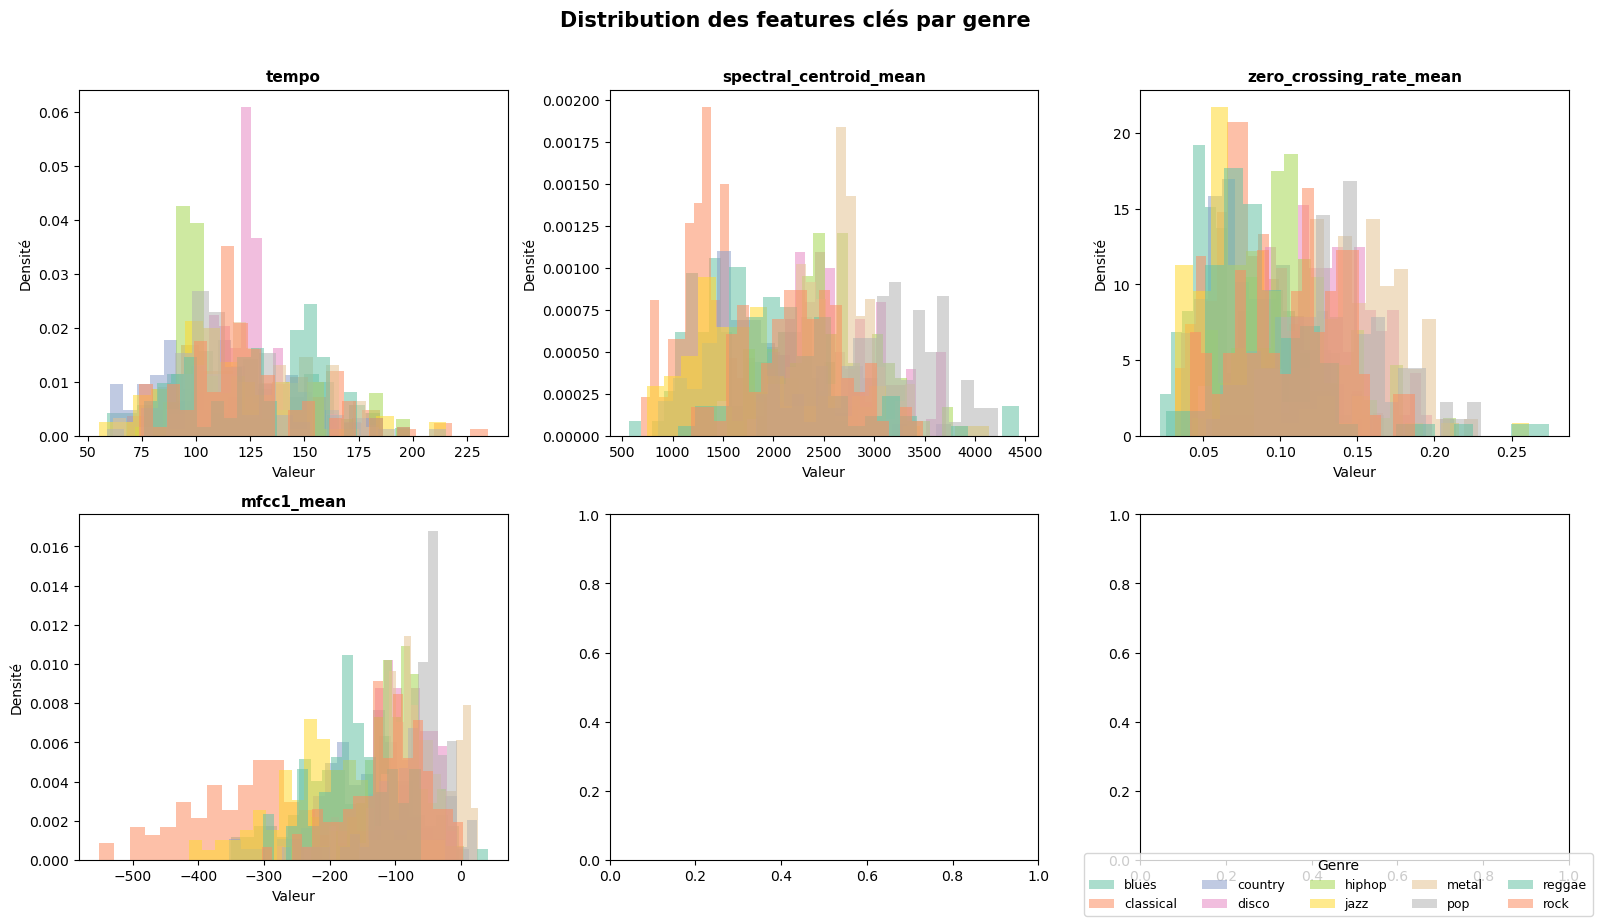

In [8]:
# Features les plus discriminantes visuellement
key_features = ['tempo', 'rmse_mean', 'spectral_centroid_mean',
                'spectral_rolloff_mean', 'zero_crossing_rate_mean', 'mfcc1_mean']

# Adapte les noms si nécessaire selon les colonnes réelles du CSV
available_keys = [f for f in key_features if f in df30.columns]
if not available_keys:
    # Fallback : on prend les premières colonnes numériques
    available_keys = feature_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(available_keys[:6]):
    for genre in GENRES:
        data = df30[df30['label'] == genre][feat]
        axes[i].hist(data, bins=20, alpha=0.55,
                     label=genre, color=GENRE_COLORS[genre], density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')

# Légende unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', ncol=5,
           fontsize=9, title='Genre', title_fontsize=10)
fig.suptitle('Distribution des features clés par genre', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

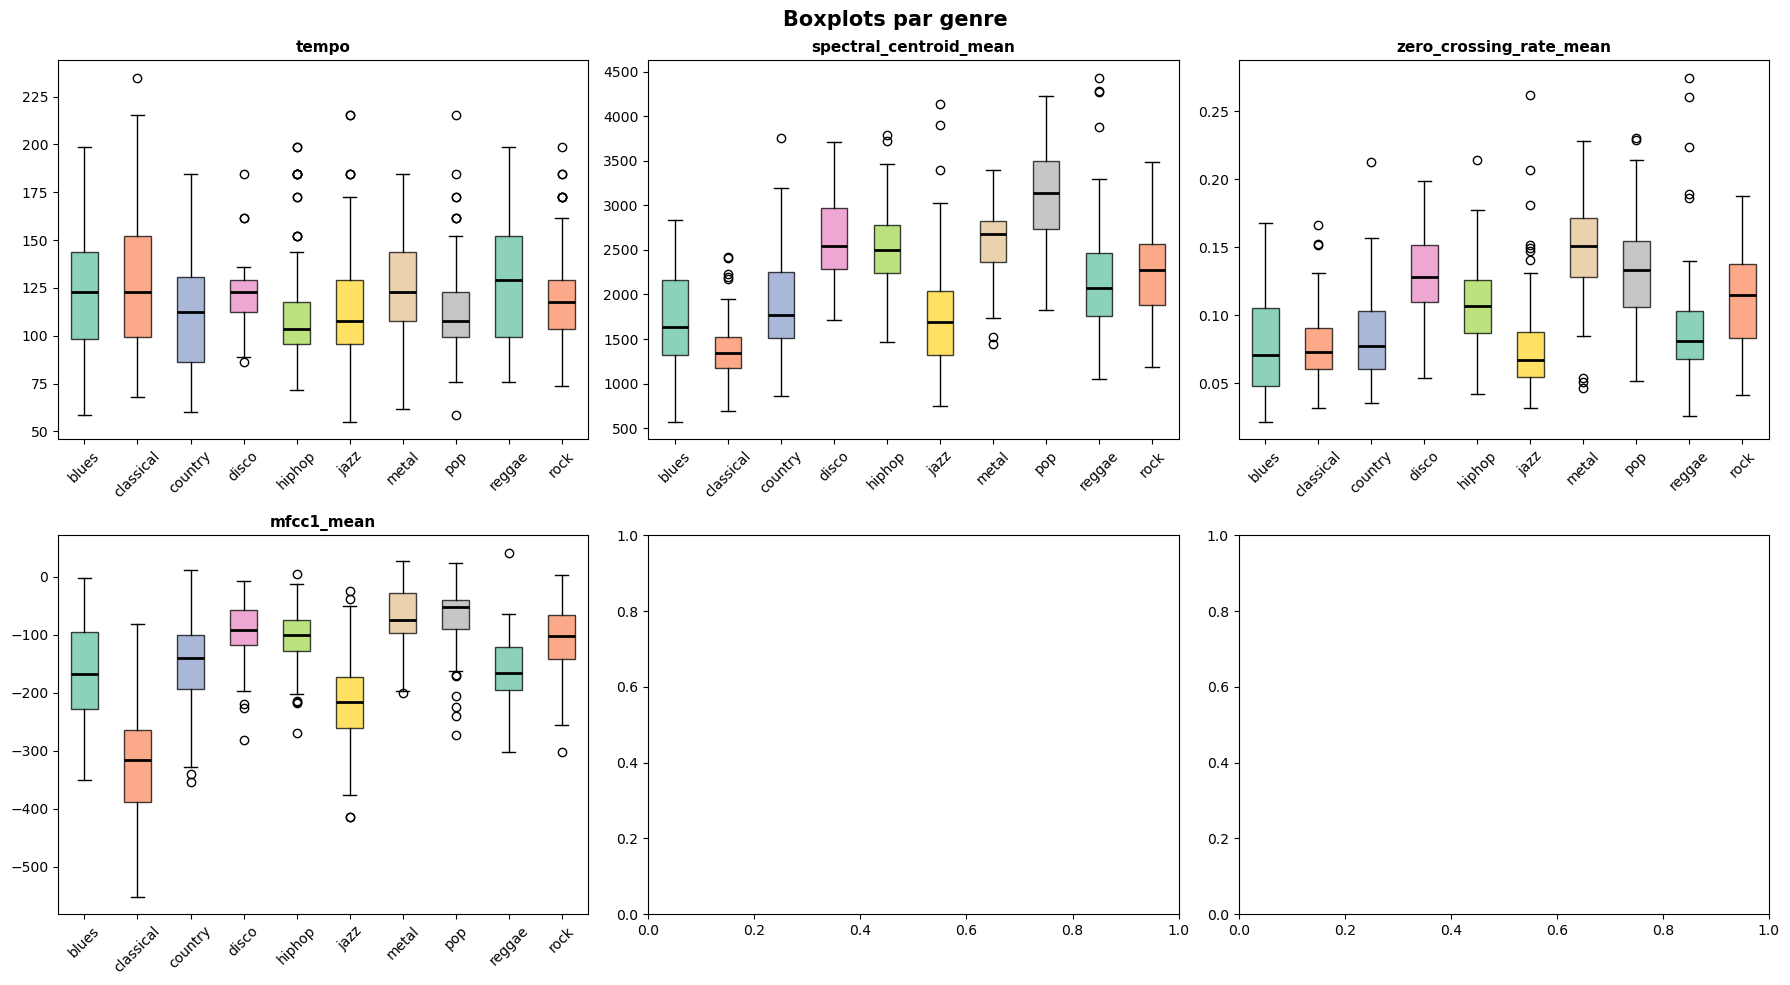

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(available_keys[:6]):
    data_by_genre = [df30[df30['label'] == g][feat].values for g in GENRES]
    bp = axes[i].boxplot(data_by_genre, labels=GENRES,
                          patch_artist=True, notch=False,
                          medianprops=dict(color='black', linewidth=2))
    for patch, genre in zip(bp['boxes'], GENRES):
        patch.set_facecolor(GENRE_COLORS[genre])
        patch.set_alpha(0.75)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Boxplots par genre', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()